# 09: Conclusions & Model Comparison

## Overview
This notebook synthesises the results of all six modelling approaches applied 
to hourly electricity demand forecasting in Zurich (ewz grid, 2022–2025).

### Research Questions
1. What weather and time variables drive electricity demand?
2. Can we predict whether a given hour will be a peak demand hour?
3. Can we model how many peak hours occur per day?

### Models
| Notebook | Model | Lead |
|---|---|---|
| 02 | Linear Model (LM) | Tamara Marcet |
| 03 | GLM Poisson | Tamara Marcet |
| 04 | GLM Binomial | Paula Barghout |
| 05 | GAM | Paula Barghout |
| 06 | Support Vector Machine (SVR) | Elena Fuchs |
| 07 | Neural Network (MLP) | Elena Fuchs |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load model comparison table
df = pd.read_csv('../outputs/model_comparison.csv')
print("Model comparison loaded ✓")
print(df.to_string())

Model comparison loaded ✓
          model      rmse       mae  r2_train     auc
0            LM  7623.700  6125.800    0.7855     NaN
1   GLM_Poisson     2.575     1.441    0.6887     NaN
2  GLM_Binomial       NaN       NaN    0.5254  0.9593
3           GAM  7199.800  5829.100    0.8081     NaN
4   NN (128,64)  2660.600  2038.200    0.9710     NaN
5           SVM   881.000   653.700    0.9967     NaN


## 1. Model Comparison

We compare all six models across relevant metrics. Note that models address 
different research questions and cannot all be compared on the same metric:

- **LM, GAM, SVM, NN** → predicting continuous demand (RMSE in kWh, R²)
- **GLM Binomial** → predicting peak/non-peak hours (AUC)
- **GLM Poisson** → predicting peak count per day (different scale)

### Why only 4 models appear in the RMSE chart below:

The GLM Poisson and GLM Binomial are excluded from the visual RMSE comparison because they address different tasks — count prediction and binary classification respectively — and are evaluated on different metrics. Including them in the same RMSE axis would be misleading. Their performance is reported separately in their own notebooks.

### Business context for the NN RMSE:

With a mean load of approximately 74,000 kW, the Neural Network's RMSE of 2,661 kW corresponds to roughly **3.6% of mean demand**, well within the operational tolerance for grid planning at EWZ.

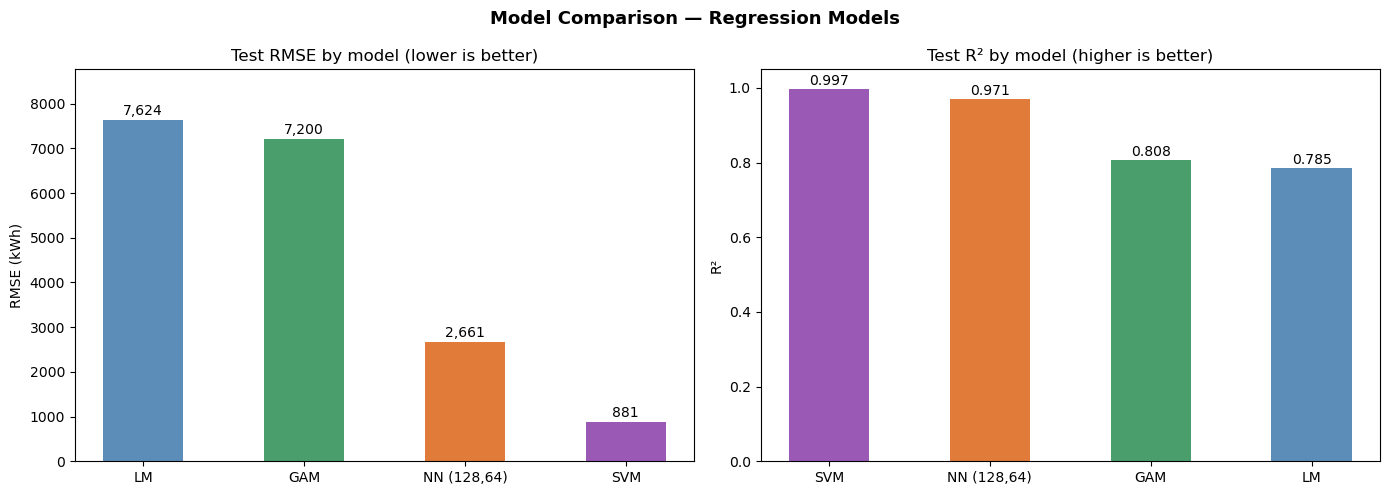

Plot saved ✓


In [2]:
# ── Regression models only (comparable on RMSE) ───────────────────────────────
reg = df[df['model'].isin(['LM', 'GAM', 'SVM', 'NN (128,64)'])].copy()
reg = reg.sort_values('rmse', ascending=False).reset_index(drop=True)
reg.columns = ['Model', 'RMSE (kWh)', 'MAE (kWh)', 'R²', 'AUC']

# Assign consistent colours per model
color_map = {
    'LM':         '#5b8db8',
    'GAM':        '#4a9e6b',
    'NN (128,64)':'#e07b3a',
    'SVM':        '#9b59b6'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Regression Models',
             fontsize=13, fontweight='bold')

# ── Panel 1: RMSE ─────────────────────────────────────────────────────────────
colors_rmse = [color_map[m] for m in reg['Model']]
axes[0].bar(reg['Model'], reg['RMSE (kWh)'], color=colors_rmse, width=0.5)
for i, v in enumerate(reg['RMSE (kWh)']):
    axes[0].text(i, v + 50, f'{v:,.0f}',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('RMSE (kWh)')
axes[0].set_title('Test RMSE by model (lower is better)')
axes[0].set_ylim(0, reg['RMSE (kWh)'].max() * 1.15)

# ── Panel 2: R² ───────────────────────────────────────────────────────────────
reg_r2 = reg.dropna(subset=['R²']).sort_values('R²', ascending=False)
colors_r2 = [color_map[m] for m in reg_r2['Model']]
axes[1].bar(reg_r2['Model'], reg_r2['R²'], color=colors_r2, width=0.5)
for i, v in enumerate(reg_r2['R²']):
    axes[1].text(i, v + 0.003, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('R²')
axes[1].set_title('Test R² by model (higher is better)')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../outputs/figures/09_conclusions/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## 2. Research Questions

**RQ1 — What weather and time variables drive electricity demand?**

Temperature and hour of day are the primary drivers. The GAM reveals a 
non-linear temperature effect: demand rises sharply below ~5°C (heating) 
and stays roughly flat above ~20°C. Hour of day shows a strong cyclic pattern 
with peaks around 8-9h and 19-20h driven by commercial and office activity.

The SVM (R²=0.997) and Neural Network (R²=0.971) both confirm that time, 
temperature, and lagged demand features explain the vast majority of demand 
variance. Notably, the SVM outperforms the NN, a reminder that on structured 
tabular data, well-tuned classical models can match or exceed deep learning approaches.

**RQ2 — Can we predict whether a given hour will be a peak demand hour?**

Yes. The GLM Binomial predicts is_peak with AUC=0.96 and 94% accuracy. Peak 
hours cluster in winter weekday mornings between 8am and 7pm. Solar radiation 
(StrGlo) reduces peak probability, likely because solar generation offsets grid 
demand during daylight hours.

**RQ3 — Can we model how many peak hours occur per day?**

The GLM Poisson captures the seasonal pattern in peak_hours_per_day reasonably 
well (R²=0.69). The main limitation is overdispersion (ratio 1.82), the data 
has more variance than the Poisson distribution assumes, so standard errors are 
underestimated. A negative binomial GLM would handle this better.

## 3. Limitations

### Poisson Overdispersion
The Poisson model shows overdispersion (ratio 1.82), meaning the data has more 
variance than the model assumes. A negative binomial GLM would handle this better.

### Summer Unpredictability
Both the SVM and NN struggle more with summer demand than winter, likely because 
summer behaviour is more influenced by irregular factors like holidays and 
heatwaves that are harder to capture with weather and time features alone.

### Data Range
Weather data is only available from 2022, which limits our ability to assess 
whether the patterns we found are representative of longer-term trends.

### Neural Network Architecture
The MLPRegressor is a relatively simple neural network architecture. Models 
like LSTM that are specifically designed for time series could potentially 
improve on our results.

### Lag Feature Dependency
Both the SVM and NN rely on lagged demand values, which assumes past demand 
is observable at prediction time. In a live forecasting setting, a short 
pipeline delay could introduce errors into the predictions.

## 4. Use of Generative AI

We used Claude (Anthropic) as a generative AI assistant throughout this project.

**What it helped with:**
- Explaining concepts such as TimeSeriesSplit, SVR hyperparameters, and why 
  log-transforming amounts stabilises variance
- Structuring notebooks with clear documentation and markdown cells
- Debugging code issues and suggesting fixes
- Suggesting and implementing lag features to improve model performance

**What was easy:**
- Generating boilerplate code for standard sklearn workflows
- Writing documentation and markdown explanations
- Suggesting visualisation approaches

**What required critical review:**
- All hyperparameter suggestions were verified and adjusted manually
- Model interpretations were cross-checked against our own understanding 
  of the data and domain
- Metric calculations were verified independently before including in the 
  comparison table

**What was impossible with AI:**
- Domain knowledge about Zurich's electricity grid had to come from us
- Final judgement on which features to include required human reasoning
- The overall narrative and research questions were defined by us, not the AI